---
title: "Chapter 11: Ensembles"
---

::: {.callout-lo}

By the end of this chapter, you will be able to:

- Broadly explain the idea of ensembles.
- Explain how prediction works in random forest models.
- Explain the sources of randomness in the random forest algorithm.
- Explain the relation between the number of estimators and the fundamental trade-off in random forests.
- Use scikit-learn's random forest classification and regression models and explain their main hyperparameters.
- Use other tree-based models such as XGBoost, LightGBM, and CatBoost.
- Broadly explain ensemble approaches, in particular model averaging and stacking.
- Use scikit-learn implementations of these ensemble methods.

:::

> The interests of truth require a diversity of opinions.
>
> — John Stuart Mill

In [1]:
#| code-fold: true
#| code-summary: "Show imports and setup"

from pathlib import Path

%matplotlib inline
import string
import sys
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path("code").resolve()))

from plotting_functions import *
from sklearn import datasets
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from utils import *
DATA_DIR = Path("data")

We now have several models in our toolbox, each with its own strengths and limitations. So far, we have mostly used cross-validation to decide which one to use. But what if two models have learned something useful? Do we have to choose just one?

Think back to predicting house prices in Chapter 10. A linear model can capture a steady increase in price as floor area increases. A decision tree can pick up different patterns in different neighbourhoods, but it assigns the same prediction to every house in a leaf. It might therefore miss a gradual change in price that the linear model captures well.

The two models could make different mistakes: one might predict too high where the other predicts too low. Averaging their predictions could bring us closer to the actual price. An **ensemble** combines predictions from multiple models, with the aim of making better predictions than an individual model.

::: {.callout-reflection}

A house sells for \$500,000. A linear model predicts \$460,000, while a decision tree predicts \$520,000. How close would their average prediction be to the actual price?

Now suppose both models predict \$460,000. Would averaging still help? What changed?

:::

In the first case, the average is \$490,000, closer to the actual price than either model's prediction. In the second, the average stays at \$460,000. Combining predictions helps in the first case because the errors partly offset each other.

This gives us two things to look for: models that make useful predictions, and models that make different mistakes. Using different model types is one way to encourage this diversity. As we will see with random forests, we can also create different versions of the same type of model. Either way, we still need validation results to tell us whether combining them actually helps.

Where do ensembles fit in today’s machine learning landscape? You may have heard a lot about deep learning and large language models (LLMs), which power applications such as conversational assistants. We have not studied these methods yet, but their prominence might make you wonder whether the models in our toolbox are still useful. For the kinds of data we have been working with, the answer is yes. Think of a table with a row for each house or transaction and columns describing its features. For this **tabular data**, tree-based ensembles remain strong candidates for tasks such as predicting house prices or detecting fraud.

Recent research helps explain why these methods are worth learning. The [2025 TabArena study](https://proceedings.neurips.cc/paper_files/paper/2025/hash/1697e3fb412da11dc9488249f9e7bbc9-Abstract-Datasets_and_Benchmarks_Track.html) compared models across many tabular datasets. Gradient-boosted trees, one of the methods we will meet in this chapter, remained competitive. Deep learning methods caught up when given more computation time and combined into ensembles, and combining different types of models improved results further.

The options are also changing. For example, [a 2025 study of TabPFN](https://www.nature.com/articles/s41586-024-08328-6), a neural model designed specifically for tables, reported strong results on datasets with up to 10,000 examples. We will not need its details here. The lesson is to compare models on your own problem, taking account of prediction quality and the time and resources they need. Tree-based ensembles deserve a place in that comparison.

::: {.callout-note collapse="true" title="Historical example: the Netflix Prize"}

How much might you enjoy a movie you have not watched yet? In 2006, Netflix launched a competition to predict the ratings users would give movies. The eventual winning solution combined hundreds of models.

Even combining just two models could help. Netflix reported individual RMSEs of 0.8914 and 0.8990; combining their predictions brought RMSE down to 0.88. Recall from Chapter 10 that lower RMSE means smaller prediction errors by this measure.

There was a practical catch, though. Netflix found that the extra gains from the final winning ensemble did not justify the engineering work needed to put it into production. A better score has to be weighed against the cost of building and maintaining the system. You can read more in [Netflix's account of the competition and its aftermath](https://netflixtechblog.com/netflix-recommendations-beyond-the-5-stars-part-1-55838468f429).

:::

We will begin with a model we already know: the decision tree. It can capture non-linear relationships without feature scaling, but a single deep tree can overfit. Could a collection of trees do better? We will explore two ways to build that collection: **random forests** and **gradient-boosted trees**.

Then we will bring different types of models together through **voting and averaging**. Finally, we will introduce **stacking**, where another model learns how to combine their predictions.

## Data

We will compare the models in this chapter using the Adult census dataset. Each row describes a person, and the target is whether their recorded annual income exceeds \$50,000. The data come from the 1994 Census database, so this is a historical prediction exercise. See the [UCI dataset description](https://archive.ics.uci.edu/dataset/2/adult) for its background.

The features include numeric measurements, such as age and hours worked per week, and categories, such as occupation and education. Before comparing models, we need a consistent way to prepare these inputs. We first set aside a test set, then replace the file's `?` markers with `np.nan` so that our imputers recognize missing entries. This replacement does not learn anything from the data.

In [2]:
adult_df_large = pd.read_csv(DATA_DIR / "adult.csv")
train_df, test_df = train_test_split(adult_df_large, test_size=0.2, random_state=42)
train_df_nan = train_df.replace("?", np.nan)
test_df_nan = test_df.replace("?", np.nan)
train_df_nan.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
5514,26,Private,256263,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,25,United-States,<=50K
19777,24,Private,170277,HS-grad,9,Never-married,Other-service,Not-in-family,White,Female,0,0,35,United-States,<=50K
10781,36,Private,75826,Bachelors,13,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32240,22,State-gov,24395,Some-college,10,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,20,United-States,<=50K
9876,31,Local-gov,356689,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K


The training data have missing entries in `workclass`, `occupation`, and `native.country`. The numeric columns, `education`, and `sex` have no missing entries in this split. The following plan builds on the preprocessing tools from Chapters 5 and 6.

| Columns | Planned preprocessing | Reason |
|---|---|---|
| `age`, `capital.gain`, `capital.loss`, `hours.per.week` | Standard scaling | Useful for the logistic-regression comparison later in the chapter; tree models do not need it. |
| `workclass`, `marital.status`, `occupation`, `relationship`, `native.country` | Fill missing values with `"missing"`, then one-hot encode | Preserve missingness as a category without imposing an order on the observed categories. |
| `education` | Ordinal encoding using the dataset's education order | Keep a compact representation that lets trees split between groups of education levels. |
| `sex` | Encode the two recorded categories as one indicator column | Represent this binary field numerically. The pipeline also provides a missing-category fallback. |
| `education.num` | Drop | It encodes the same education levels, so retaining both would duplicate that information. |
| `fnlwgt` | Drop | This is a census sampling weight. We are using an unweighted prediction exercise rather than estimating population quantities. |
| `race` | Drop | We omit it from the predictors in this demonstration. This choice does not guarantee fair predictions. |

For this comparison, we include the recorded `sex` field as a predictor. Its inclusion is a modelling choice, not a requirement. Its two categories do not represent the full range of sex or gender identities. As discussed in Chapter 9, aggregate scores can hide differences in model performance across groups.

Let's translate the table into column groups.

In [3]:
numeric_features = ["age", "capital.gain", "capital.loss", "hours.per.week"]

categorical_features = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "native.country",
]

ordinal_features = ["education"]
binary_features = ["sex"]
drop_features = ["fnlwgt", "race", "education.num"]
target_column = "income"

For `education`, we use the order recorded by `education.num` in this dataset. This is a coding convention, not a universal ranking of qualifications. In particular, `Some-college` comes after `HS-grad`, and `Prof-school` comes between `Masters` and `Doctorate`.

Ordinal encoding also makes an assumption worth remembering: in a linear model, each step in the code has the same effect on the prediction. A tree can split at different thresholds without making that equal-effect assumption. One-hot encoding education is a reasonable alternative, especially for a linear model; we keep the ordinal representation here for continuity with the tree examples.

In [4]:
education_levels = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate",
]

In [5]:
# Check that the explicit order matches the dataset's education codes.
education_order = (
    train_df[["education", "education.num"]]
    .drop_duplicates()
    .sort_values("education.num")["education"]
    .tolist()
)
assert education_levels == education_order

Now we can assemble the transformations in a `ColumnTransformer`. For the categorical columns, `handle_unknown="ignore"` allows a category that was absent during fitting to appear later; its one-hot indicators will all be zero. We request dense output from this branch because some of the boosting models used later require dense inputs.

This defines the preprocessing but does not fit it. We will place it inside each model's pipeline, so cross-validation learns scaling statistics and observed categories using only the training portion of each fold.

In [6]:
numeric_transformer = StandardScaler()

ordinal_transformer = OrdinalEncoder(categories=[education_levels], dtype=int)

binary_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(drop="if_binary", dtype=int),
)
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (ordinal_transformer, ordinal_features),
    (binary_transformer, binary_features),
    (categorical_transformer, categorical_features),
    ("drop", drop_features),
)

In [7]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('ordinalencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_

Next, separate the input columns from the target. We keep the test set aside for evaluation after model selection.

In [8]:
X_train = train_df_nan.drop(columns=[target_column])
y_train = train_df_nan[target_column]

X_test = test_df_nan.drop(columns=[target_column])
y_test = test_df_nan[target_column]

Before choosing an evaluation metric, let's check the class proportions in the training set.

In [9]:
train_df["income"].value_counts(normalize=True)

income
<=50K    0.757985
>50K     0.242015
Name: proportion, dtype: float64

About 76% of the training examples belong to the `<=50K` class. A classifier that always predicts that class would therefore achieve about 76% accuracy, which gives us an important baseline.

For this chapter, we will use accuracy to keep the comparison focused on ensemble methods. It counts every incorrect prediction equally, but the majority class contributes more examples to the score. As Chapter 9 showed, a real application may call for precision, recall, or another metric depending on the consequences of errors. Class imbalance alone does not tell us which metric to choose or whether to apply class weights.

In [10]:
scoring_metric = "accuracy"

We will also use models outside scikit-learn that require integer target labels. `LabelEncoder` gives us a consistent mapping from the two income categories to 0 and 1. This encodes the target only; the feature transformations remain in the preprocessing pipeline. We learn the mapping from the training labels and reuse it for the test labels.

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_num = label_encoder.fit_transform(y_train)
y_test_num = label_encoder.transform(y_test)

In [12]:
y_train_num

array([0, 0, 0, ..., 1, 1, 0], shape=(26048,))

## Setting up the model comparison

As we try more models, how will we keep track of what actually improves? We need a consistent comparison and a place to collect the evidence. We will use the same training data, cross-validation splits, and accuracy metric for every candidate. Each model's preprocessing stays inside its pipeline so that it is fitted separately within each fold. The reserved test set does not take part in this comparison.

We use five stratified folds, which keep approximately the same class proportions in each fold. Creating the splits once makes it explicit that every candidate is evaluated on the same held-out rows. These indices refer only to `X_train` and `y_train_num`.

The dictionary `cv_results` will store the full output of `cross_validate` under a descriptive model name. Each entry contains an array of scores and timings across the folds, rather than just a single average. Keeping these values lets us inspect individual folds or summarize them differently later.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
cv_splits = list(cv.split(X_train, y_train_num))
cv_results = {}

Our first reference is a `DummyClassifier`. With its default strategy, it predicts the most frequent training class without using the features. This tells us how much accuracy we can achieve before learning any relationship between the inputs and the target. `return_train_score=True` also records training scores, so we can compare training and validation performance.

In [14]:
dummy = DummyClassifier()
cv_results["Dummy"] = cross_validate(
    dummy, X_train, y_train_num, cv=cv_splits, return_train_score=True, scoring=scoring_metric
)

Next, fit a single decision tree using our preprocessing pipeline. This is a more demanding reference: an ensemble should justify its extra computation by improving on a model that already uses the features.

In [15]:
pipe_dt = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=123))
cv_results["decision tree"] = cross_validate(
    pipe_dt, X_train, y_train_num, cv=cv_splits, return_train_score=True, scoring=scoring_metric
)

Now summarize the fold results in a table. We retain numeric values so that we can sort or plot them later. The standard deviation below uses NumPy's default convention, matching Chapter 10.

In [16]:
pd.DataFrame({
    name: {
        "mean training accuracy": scores["train_score"].mean(),
        "mean validation accuracy": scores["test_score"].mean(),
        "validation accuracy std": scores["test_score"].std(),
        "mean fit time (s)": scores["fit_time"].mean(),
        "mean score time (s)": scores["score_time"].mean(),
    }
    for name, scores in cv_results.items()
}).T

,mean training accuracy,mean validation accuracy,validation accuracy std,mean fit time (s),mean score time (s)
Dummy,0.757985,0.757985,0.000065,0.001560,0.000282
decision tree,0.978722,0.820293,0.003746,0.072569,0.005458


The table gives each model one row, making it easier to compare several kinds of evidence:

- **Mean training and validation accuracy:** a large gap suggests the model fits the training examples much better than new examples. Training accuracy alone is not a reason to choose a model.
- **Validation accuracy standard deviation:** describes how much the score varies across these folds. It is not a confidence interval, and a small difference in mean scores does not establish that one model will reliably outperform another.
- **Mean fit time:** includes fitting the preprocessing steps and the model within each fold.
- **Mean score time:** includes making predictions and computing the validation score. It is a useful comparison here, but not a direct measurement of prediction latency in a deployed application.

The `test_score` key returned by `cross_validate` refers to each held-out validation fold, not our reserved test set. We label it “validation accuracy” in the table to keep that distinction clear.

Compare the decision tree's training and validation scores. A deep tree can fit the training data very closely while making more mistakes on held-out examples. That gap motivates our next question: can combining several trees improve validation performance?

We will extend this table as we introduce new models. It guides model selection; the test set remains reserved for evaluating the selected approach. Repeatedly adapting choices to cross-validation results can also overfit those results, so we should keep the comparison purposeful.

We will need the same summary after evaluating each new model. Let's put just the table construction into a small helper. It does not fit models or run cross-validation; those steps remain explicit.

In [17]:
def comparison_table(cv_results):
    """Summarize stored fold scores and timings without fitting models."""
    return pd.DataFrame({
        name: {
            "mean training accuracy": scores["train_score"].mean(),
            "mean validation accuracy": scores["test_score"].mean(),
            "validation accuracy std": scores["test_score"].std(),
            "mean fit time (s)": scores["fit_time"].mean(),
            "mean score time (s)": scores["score_time"].mean(),
        }
        for name, scores in cv_results.items()
    }).T

## Random forests

Our single decision tree fits the training data much better than the validation data. We would like to keep its ability to learn flexible relationships while making its predictions more reliable. One possibility is to combine several trees: a pattern picked up by only one tree might have less influence on their average prediction.

But there is a catch. If we train trees in exactly the same way on the same data, they may all make the same mistakes. Averaging identical predictions changes nothing. A **random forest** encourages the trees to differ by introducing randomness during training.

### Building a diverse collection of trees

The first source of randomness is the training data each tree sees. For a training set of $n$ rows, we draw $n$ rows **with replacement**: after selecting a row, we put it back so it can be selected again. This is a **bootstrap sample**. It has the same number of rows as the original training set, but some rows appear more than once and others are absent.

For example, suppose our training rows have identifiers `[0, 1, 2, 3, 4, 5]`. Three bootstrap samples might look like this:

| Tree | Bootstrap sample |
|---|---|
| 1 | `[1, 1, 3, 3, 3, 4]` |
| 2 | `[3, 2, 2, 2, 1, 1]` |
| 3 | `[0, 0, 0, 4, 4, 5]` |

Each tree draws its own sample independently. Independent draws do not guarantee distinct samples, although identical samples are unlikely for a large dataset. Training models on bootstrap samples and combining their predictions is called **bagging**, short for *bootstrap aggregating*.

Bootstrap sampling encourages different trees, but they may still resemble one another. Imagine that education is a particularly useful predictor of income. Many trees might choose it near the root, even when trained on different samples.

A random forest adds a second source of randomness: **at each split, consider only a random subset of the features**. The tree then chooses the best split among those candidates. A feature excluded at one split can be available at another. This gives other features a chance to influence the tree and helps avoid a collection of trees that all rely on the same early decisions.

The aim is a balance: each tree should learn useful patterns, while the trees should make different mistakes. Too little randomness can leave the trees very similar; too much can make individual trees less useful.

::: {.callout-reflection}

Suppose we choose a random subset of features once for each tree, instead of choosing a new subset at every split. What happens to a tree that never receives an important feature? How does selecting a new subset at each split change this?

:::

::: {.callout-tip collapse="true" title="Discussion"}

With one subset per tree, an excluded feature is unavailable everywhere in that tree. With a new subset per split, the feature can become available further down the tree. This allows randomness without permanently removing potentially useful information from each tree.

:::

### From individual trees to a forest prediction

Let's inspect a small forest with three trees, each limited to depth two. These limits make the trees readable; they are not a recommendation for a full predictive model. `random_state` makes the random choices reproducible.

We clone the preprocessing configuration so this fitted demonstration has its own preprocessor. Feature names come from that fitted transformer, in the same order as the columns supplied to the trees.

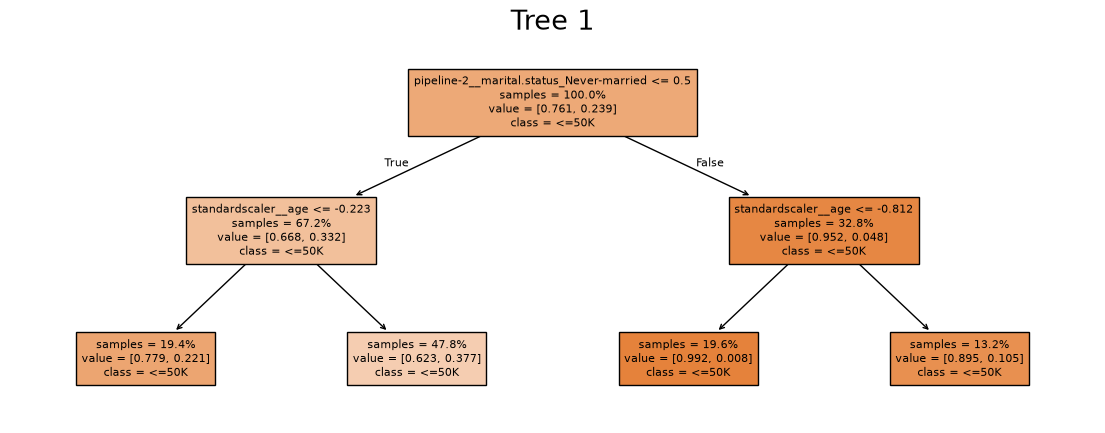

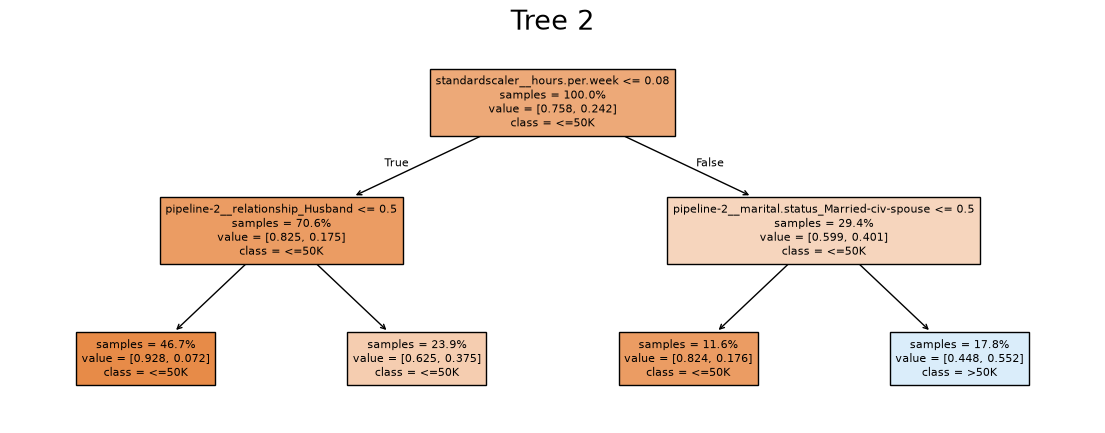

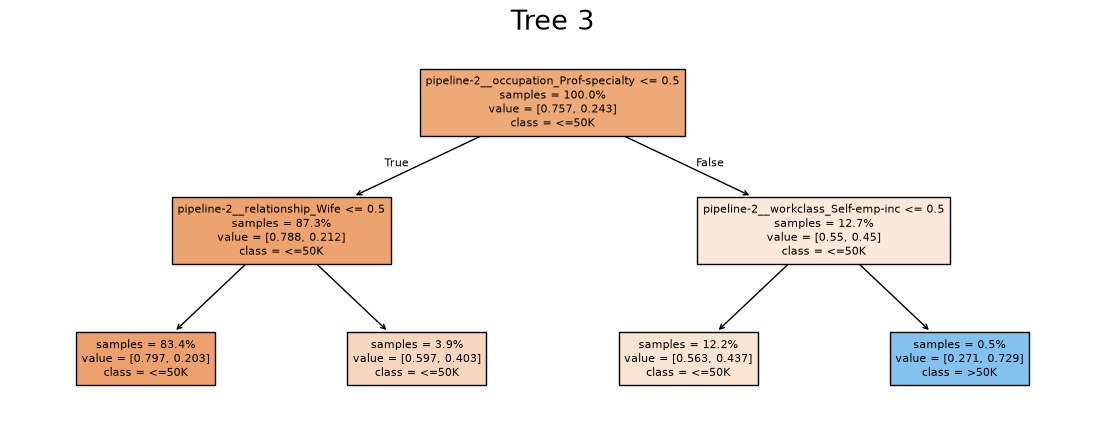

In [18]:
from sklearn.base import clone
from sklearn.tree import plot_tree

pipe_rf_demo = make_pipeline(
    clone(preprocessor),
    RandomForestClassifier(n_estimators=3, max_depth=2, random_state=123),
)
pipe_rf_demo.fit(X_train, y_train_num)
demo_preprocessor = pipe_rf_demo.named_steps["columntransformer"]
demo_forest = pipe_rf_demo.named_steps["randomforestclassifier"]
feature_names = demo_preprocessor.get_feature_names_out()

for i, tree in enumerate(demo_forest.estimators_, start=1):
    fig, ax = plt.subplots(figsize=(14, 5))
    plot_tree(
        tree, feature_names=feature_names,
        class_names=label_encoder.classes_.tolist(),
        filled=True, impurity=False, proportion=True, fontsize=8, ax=ax,
    )
    ax.set_title(f"Tree {i}")
    plt.show()

Look at the features and thresholds chosen by the three trees. Even with the same maximum depth, the trees need not ask the same questions. Numeric thresholds are in standardized units because these trees receive the preprocessed features. The `value` entries give class proportions in the order `<=50K`, `>50K`; these supply the probabilities when an example reaches a leaf.

Now trace one training example through the forest. We use this row only to illustrate the prediction calculation; its prediction is not an estimate of generalization performance. Each tree returns class probabilities from the leaf the example reaches. For classification, scikit-learn's forest averages those probabilities and selects the class with the largest average. This can differ from a majority vote on the trees' class labels. See the [prediction documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier.predict_proba).

In [19]:
demo_example = X_train.iloc[[0]]
transformed_example = demo_preprocessor.transform(demo_example)
tree_probabilities = np.vstack([
    tree.predict_proba(transformed_example)[0]
    for tree in demo_forest.estimators_
])
probability_table = pd.DataFrame(
    tree_probabilities,
    index=[f"Tree {i}" for i in range(1, 4)],
    columns=label_encoder.classes_,
)
probability_table.loc["Average"] = tree_probabilities.mean(axis=0)
probability_table.loc["Forest predict_proba"] = pipe_rf_demo.predict_proba(demo_example)[0]
probability_table

,<=50K,>50K
Tree 1,0.992222,0.007778
Tree 2,0.927500,0.072500
Tree 3,0.796607,0.203393
Average,0.905443,0.094557
Forest predict_proba,0.905443,0.094557


In [20]:
predicted_code = pipe_rf_demo.predict(demo_example)
label_encoder.inverse_transform(predicted_code)

array(['<=50K'], dtype=object)

The last two rows agree: the forest uses the average of the individual trees' probabilities. The selected class is the column with the larger average.

For regression, each tree instead predicts a number, and `RandomForestRegressor` averages those numbers. In both cases, the forest combines predictions from trees that were trained independently; a tree does not learn from the predictions of earlier trees.

### Evaluating and configuring a random forest

Now fit a larger forest without the depth limit used for visualization. We keep the preprocessing, metric, and cross-validation folds from the baseline comparison. Since the trees can be trained independently, `n_jobs=-1` allows scikit-learn to use all available processors for the forest. We leave the outer cross-validation loop sequential to avoid requesting parallel work at both levels.

In [21]:
pipe_rf = make_pipeline(
    clone(preprocessor),
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=123),
)
cv_results["random forest"] = cross_validate(
    pipe_rf, X_train, y_train_num, cv=cv_splits,
    return_train_score=True, scoring=scoring_metric,
)
comparison_table(cv_results)

,mean training accuracy,mean validation accuracy,validation accuracy std,mean fit time (s),mean score time (s)
Dummy,0.757985,0.757985,0.000065,0.001560,0.000282
decision tree,0.978722,0.820293,0.003746,0.072569,0.005458
random forest,0.978703,0.848126,0.002228,0.127936,0.019166


In this run, the forest raises mean validation accuracy from about 82.0% for the single tree to 84.8%. Compare their fitting and scoring times as well: the improvement requires additional computation. A forest can still have a high training score and a training–validation gap. Averaging does not make overfitting impossible; the useful question is whether it improves predictions on held-out examples.

Several hyperparameters control different aspects of the forest:

| Hyperparameter | What it controls | Practical effect |
|---|---|---|
| `n_estimators` | Number of trees | More trees can stabilize the average, at a cost in computation and memory. |
| `max_depth` | Maximum depth of each tree | Smaller values restrict the patterns each tree can fit. |
| `min_samples_leaf` | Minimum number of samples in a leaf | Larger values prevent leaves supported by very few samples and can reduce overfitting. |
| `max_features` | Number of candidate features considered at each split | Fewer candidates encourage differences between trees, but may also weaken individual trees. |

**Adding trees is different from making each tree deeper.** Greater depth allows a tree to fit finer details. Adding trees instead averages more predictions from the same training procedure. Its benefit often levels off as the average becomes stable. Validation accuracy need not improve at every step.

::: {.callout-reflection}

Before running the next cell, sketch how you expect training and validation accuracy to change as we add trees while keeping the other settings fixed. Would you expect the same curves if we increased tree depth instead?

:::

We will compare a short list of forest sizes using the same five folds. This takes longer than a single fit, so we keep the list small and reuse the 100-tree result already computed. The test set remains untouched.

In [22]:
tree_count_results = {100: cv_results["random forest"]}
for n_trees in [1, 5, 25, 200]:
    candidate = clone(pipe_rf).set_params(randomforestclassifier__n_estimators=n_trees)
    tree_count_results[n_trees] = cross_validate(
        candidate, X_train, y_train_num, cv=cv_splits,
        return_train_score=True, scoring=scoring_metric,
    )

tree_count_summary = comparison_table(tree_count_results).sort_index()
tree_count_summary.index.name = "Number of trees"
tree_count_summary

,mean training accuracy,mean validation accuracy,validation accuracy std,mean fit time (s),mean score time (s)
Number of trees,,,,,
1,0.919533,0.807547,0.005809,0.032136,0.006100
5,0.961177,0.836148,0.003031,0.030486,0.018078
25,0.976802,0.845132,0.002071,0.057976,0.018548
100,0.978703,0.848126,0.002228,0.127936,0.019166
200,0.978722,0.847819,0.002750,0.216377,0.030928


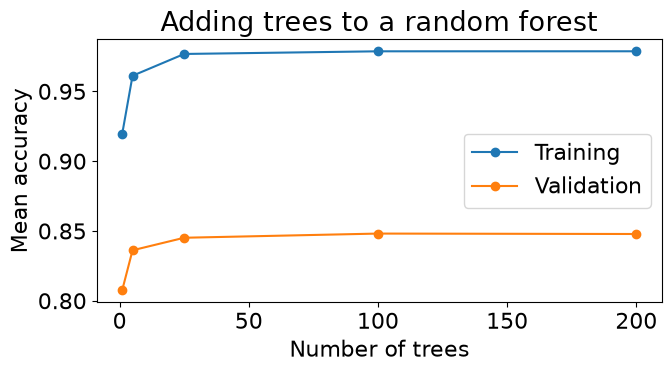

In [23]:
ax = tree_count_summary[
    ["mean training accuracy", "mean validation accuracy"]
].plot(marker="o", figsize=(7, 4))
ax.set(xlabel="Number of trees", ylabel="Mean accuracy", title="Adding trees to a random forest")
ax.legend(["Training", "Validation"])
plt.tight_layout()
plt.show()

The validation curve begins to level off as the forest grows. In this run, increasing from 100 to 200 trees does not improve mean validation accuracy, but it does increase fit time. Compare these scores with their variation across folds before reading much into a small difference. A small score improvement may not justify a much larger forest. More trees can reduce sensitivity to the random seed, but they cannot repair an unsuitable feature representation or remove patterns shared by all the trees' errors.

If validation performance remains poor, investigate the individual trees' settings as well as the forest size. Restricting depth or increasing `min_samples_leaf` may help when the trees fit overly specific patterns. Very restrictive settings can instead underfit. Use validation results to choose among these possibilities rather than treating any hyperparameter as a universal improvement.

### When to use a random forest

A random forest is a useful candidate for tabular prediction when relationships may be non-linear and it is not obvious which feature combinations matter. It offers a way to extend the decision-tree workflow without manually specifying those combinations. Tree models do not require feature scaling; we retained it here so the same preprocessing plan can also support our linear-model comparison.

The costs matter too. A forest stores many trees and evaluates them at prediction time, so it uses more memory and computation than a single tree. Parallel training can help with speed, but does not remove that work. We also lose the simplicity of explaining a prediction by following just one tree. For high-dimensional sparse inputs such as word-count features, compare against the linear models we already know rather than assuming a forest will be preferable.

Start with a moderately sized forest, inspect its cross-validation results, and decide whether further tuning is worth the cost. Reproducibility comes from a fixed `random_state`; confidence in the model comes from appropriate evaluation, not from choosing a seed that happens to give a good score.

::: {.callout-note collapse="true" title="Further reading"}

[`ExtraTreesClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html) introduces additional randomness in candidate split thresholds. It is another ensemble to compare, rather than an automatically better forest. For the original development of random forests, see [Breiman (2001)](https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf).

:::

### Exercise 11.1: Choosing the next experiment

Suppose a forest with 100 deep trees has training accuracy 0.99 and mean validation accuracy 0.85. Increasing to 200 trees produces scores of 0.99 and 0.851, with roughly twice the fit time.

1. Would you conclude that increasing the number of trees is the most promising next step? Explain.
2. Suggest one change to the individual trees and explain both its possible benefit and its risk.
3. Which data should you use to compare these choices?

::: {.callout-tip collapse="true" title="Solution"}

1. The additional trees produced only a small validation improvement. We should inspect variation across folds and the computational cost before treating it as worthwhile. These results do not show that adding many more trees will resolve the training–validation gap.
2. Try reducing `max_depth` or increasing `min_samples_leaf`. Either can discourage fitting very specific training patterns, but too much restriction can cause underfitting. The gap motivates this experiment; it does not guarantee an improvement.
3. Compare using cross-validation within the training set, keeping the reserved test set out of these decisions.

:::

A random forest trains trees independently and combines their predictions. Next, we will explore a different approach: building trees in sequence so that each new tree improves the current ensemble's predictions.

## Gradient boosted trees

Random forests build trees independently and average their predictions. Could we instead ask each new tree to improve the prediction we already have? This is the idea behind **boosting**. We start with a simple prediction, then build a sequence of trees that make corrections. Each tree depends on the ensemble built so far.

### Building trees that correct earlier predictions

Let's return briefly to regression, where we can see the corrections directly. Suppose we want to predict house prices from floor area and measure error using squared loss. A starting prediction is the mean training price. For each house, we compute a **residual**: its actual price minus the current prediction. A positive residual means we predicted too low; a negative residual means we predicted too high.

We fit a small regression tree using the original features as inputs and these residuals as its target. The tree learns where to raise or lower our predictions. We then add its predicted corrections to the current predictions and recompute the residuals before fitting the next tree. Each new tree tries to improve the whole ensemble, rather than just the immediately preceding tree.

Here is a small invented dataset. Prices are in thousands of dollars. We will use trees with only one split, called **decision stumps**, so that each correction stays simple.

In [24]:
from sklearn.tree import DecisionTreeRegressor

X_boost_demo = pd.DataFrame({"floor_area": [50, 70, 90, 110, 130, 150]})
y_boost_demo = np.array([200, 220, 260, 300, 340, 360], dtype=float)
initial_prediction = y_boost_demo.mean()
current_prediction = np.full(len(y_boost_demo), initial_prediction)
learning_rate = 0.5
boost_steps = pd.DataFrame({
    "floor area": X_boost_demo["floor_area"],
    "actual price": y_boost_demo,
    "initial prediction": current_prediction.copy(),
})
correction_trees = []
for step in range(1, 3):
    residuals = y_boost_demo - current_prediction
    tree = DecisionTreeRegressor(max_depth=1, random_state=123)
    tree.fit(X_boost_demo, residuals)
    correction = tree.predict(X_boost_demo)
    current_prediction = current_prediction + learning_rate * correction
    correction_trees.append(tree)
    boost_steps[f"residual before step {step}"] = residuals
    boost_steps[f"tree {step} correction"] = correction
    boost_steps[f"prediction after step {step}"] = current_prediction.copy()
boost_steps.round(1)

,floor area,actual price,initial prediction,residual before step 1,tree 1 correction,prediction after step 1,residual before step 2,tree 2 correction,prediction after step 2
0,50,200.0,280.0,-80.0,-53.3,253.3,-53.3,-43.3,231.7
1,70,220.0,280.0,-60.0,-53.3,253.3,-33.3,-43.3,231.7
2,90,260.0,280.0,-20.0,-53.3,253.3,6.7,21.7,264.2
3,110,300.0,280.0,20.0,53.3,306.7,-6.7,21.7,317.5
4,130,340.0,280.0,60.0,53.3,306.7,33.3,21.7,317.5
5,150,360.0,280.0,80.0,53.3,306.7,53.3,21.7,317.5


Read the first row from left to right. The initial prediction is 280, but the actual price is 200, giving a residual of −80. The first tree groups several houses together and predicts a correction of about −53.3 for this row. It does not reproduce every residual exactly. With `learning_rate=0.5`, we apply half the correction, lowering the prediction to about 253.3. The next tree is fitted to the errors that remain.

The **learning rate** controls how much of each correction we apply. If a tree predicts a correction of 10 and the learning rate is 0.1, the ensemble prediction increases by 1. Taking smaller steps gives later trees opportunities to refine the result.

At prediction time, we start with the same initial value and add the scaled predictions from all the correction trees. We do not average them as in a random forest: each tree learned a correction, not a stand-alone estimate of the original target.

In [25]:
new_house = pd.DataFrame({"floor_area": [100]})
boosted_prediction = initial_prediction + learning_rate * sum(
    tree.predict(new_house)[0] for tree in correction_trees
)
boosted_prediction  # Price in thousands of dollars

np.float64(264.16666666666663)

This residual-fitting procedure describes gradient boosting for **squared-error regression**. Other losses require different corrections. In classification, we update numerical scores that are converted to probabilities, rather than repeatedly subtracting predicted class labels from observed labels.

The word **gradient** refers to determining a direction in which changing the predictions reduces the loss. A new tree approximates that desired correction. We do not need calculus to use the models here, but it matters that the correction depends on the loss we are trying to reduce.

### Controlling how much the ensemble learns

Small trees can be useful building blocks even when one such tree would underfit on its own. Adding successive corrections makes the combined model more flexible. That flexibility also creates a risk: eventually, new trees may fit peculiarities of the training data instead of patterns that generalize.

| Choice | What it controls | What to watch for |
|---|---|---|
| Number of boosting rounds | How many successive corrections we make | Too few can underfit; too many can worsen validation performance. |
| Learning rate | How much of each correction we apply | Smaller steps often need more rounds; smaller is not automatically better. |
| Tree size | How complicated each correction can be | Deeper trees or more leaves can capture richer patterns but also fit noise. |

These settings work together. Compare combinations using validation data rather than tuning one setting in isolation. Names vary: boosting rounds are commonly called `n_estimators`, `max_iter` in scikit-learn's histogram implementation, and `iterations` in CatBoost. Tree size may be controlled by depth, number of leaves, or minimum leaf size.

Unlike adding random-forest trees, adding boosting rounds changes the function we are learning through successive corrections. We cannot assume that more rounds will simply stabilize the prediction. Boosting can also use random row or feature sampling; sequential learning does not mean that the algorithm has no randomness.

**Early stopping** monitors a validation score or loss during training and stops when further rounds stop helping. Any data used for that decision are part of model selection. Within cross-validation, an early-stopping validation set should come from the training portion of the fold, leaving the outer held-out fold for evaluation. Our reserved test set must not be used to decide when to stop.

### Different implementations of the same idea

Several libraries implement gradient-boosted trees. They share the idea of successive corrections but differ in how they construct trees, control complexity, and represent features. The following distinctions explain why it can be worth comparing them; none establishes a universal winner.

| Implementation | What distinguishes it? |
|---|---|
| scikit-learn `GradientBoostingClassifier` | A familiar starting point that searches split thresholds without first grouping numeric values into histogram bins. |
| scikit-learn `HistGradientBoostingClassifier` | Groups numeric values into bins to speed up split searches, which is useful as datasets grow. See the [scikit-learn overview](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting). |
| XGBoost | Combines efficient tree building with explicit penalties on tree complexity and leaf predictions, offering several controls against overfitting. See its [boosted-tree introduction](https://xgboost.readthedocs.io/en/stable/tutorials/model.html). |
| LightGBM | Uses histogram-based searches and typically expands the leaf whose split offers the greatest improvement. Trees can grow unevenly, making leaf and depth limits important. See its [feature overview](https://lightgbm.readthedocs.io/en/latest/Features.html). |
| CatBoost | Provides built-in handling of categorical features, including target-based category statistics constructed without using a row's own target to encode that row during training. See its [categorical-feature explanation](https://catboost.ai/docs/en/concepts/algorithm-main-stages_cat-to-numberic). |

These are distinguishing emphases, not exclusive capabilities. For instance, categorical-feature support is not unique to CatBoost. We can begin with familiar preprocessing and then investigate model-specific options when there is a reason to do so.

### Comparing boosting models on our dataset

Let's return to income classification. We will use the same cross-validation folds and results table as before. The boosting candidates below use 100 rounds, a learning rate of 0.1, and modest tree sizes. These are explicit starting settings, not tuned configurations. Equal round counts and depth limits do not make the models equally complex or give them equal computation budgets.

We disable early stopping in the histogram model so that it also completes the specified number of rounds. The external libraries expose familiar `fit` and `predict` methods, allowing us to use them in scikit-learn pipelines. If needed, install them from the project root with `uv add xgboost lightgbm catboost`.

We retain the common encoded feature representation for this first comparison. In particular, CatBoost receives encoded numeric columns here, so this example does not demonstrate its native categorical handling. We also add logistic regression as a reference and reuse the already evaluated tree and forest. All candidates use unweighted training; class weighting would be a separate choice to investigate based on our evaluation goal.

In [26]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier

pipe_lr = make_pipeline(clone(preprocessor), LogisticRegression(max_iter=2000, random_state=123))
pipe_xgb = make_pipeline(
    clone(preprocessor),
    XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                  n_jobs=2, random_state=123),
)
pipe_lgbm = make_pipeline(
    clone(preprocessor),
    LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                   num_leaves=8, n_jobs=2, random_state=123, verbosity=-1),
)
pipe_catboost = make_pipeline(
    clone(preprocessor),
    CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3,
                       thread_count=2, random_seed=123, verbose=False,
                       allow_writing_files=False),
)
pipe_sklearn_histGB = make_pipeline(
    clone(preprocessor),
    HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1,
                                   max_depth=3, max_leaf_nodes=8,
                                   early_stopping=False, random_state=123),
)
pipe_sklearn_GB = make_pipeline(
    clone(preprocessor),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                               max_depth=3, random_state=123),
)
classifiers = {
    "logistic regression": pipe_lr,
    "decision tree": pipe_dt,
    "random forest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM": pipe_lgbm,
    "CatBoost": pipe_catboost,
    "sklearn_histGB": pipe_sklearn_histGB,
    "sklearn_GB": pipe_sklearn_GB,
}

In [27]:
for name, model in classifiers.items():
    if name in cv_results:
        continue  # Reuse the unchanged tree and forest baselines.
    cv_results[name] = cross_validate(
        model, X_train, y_train_num, cv=cv_splits,
        return_train_score=True, scoring=scoring_metric,
    )
comparison_table(cv_results).sort_values("mean validation accuracy", ascending=False)

,mean training accuracy,mean validation accuracy,validation accuracy std,mean fit time (s),mean score time (s)
sklearn_GB,0.870182,0.865786,0.002250,1.324264,0.008394
XGBoost,0.868541,0.864443,0.002358,0.100654,0.006627
LightGBM,0.868464,0.864212,0.002838,0.073364,0.007917
sklearn_histGB,0.868262,0.864174,0.002884,0.187363,0.008970
CatBoost,0.863809,0.861947,0.003329,0.179038,0.006502
logistic regression,0.853684,0.853348,0.003866,0.130447,0.011052
random forest,0.978703,0.848126,0.002228,0.127936,0.019166
decision tree,0.978722,0.820293,0.003746,0.072569,0.005458
Dummy,0.757985,0.757985,0.000065,0.001560,0.000282


Read accuracy and computation time together. Does a boosting candidate improve on the single tree, random forest, and logistic regression? Are the differences large compared with the variation across folds? A high training score alone does not establish a better model, and similar validation scores can make the cheaper model more attractive.

In this run, the boosting candidates achieve about 86.2–86.6% mean validation accuracy, compared with about 85.3% for logistic regression and 84.8% for the random forest. Their scores are close, while fitting times differ: the classic scikit-learn implementation takes noticeably longer than the histogram implementation here. These results give us candidates to investigate, rather than a decisive winner.

This comparison describes these configurations on this dataset. It is not a ranking of the libraries in general. Defaults, preprocessing choices, tuning budgets, software versions, and hardware can all affect the result. If two candidates look promising, a focused search over learning rate, rounds, and tree size is a sensible next step.

::: {.callout-note collapse="true" title="Optional: let CatBoost handle categorical columns"}

For native categorical handling, we supply a DataFrame and tell CatBoost which columns contain categories. We keep the same selected input columns but treat `education` as categorical too. Missing categorical entries must be represented explicitly; replacing them with a fixed string does not learn statistics from the data. CatBoost learns its category representations during each fold's fit. We pass the categorical column names as fit parameters through `cross_validate`.

```python
catboost_categories = categorical_features + ordinal_features + binary_features
X_train_native = X_train[numeric_features + catboost_categories].copy()
X_train_native[catboost_categories] = (
    X_train_native[catboost_categories].fillna("missing").astype(str)
)
native_catboost = CatBoostClassifier(
    iterations=100, learning_rate=0.1, depth=3,
    thread_count=2, random_seed=123, verbose=False,
    allow_writing_files=False,
)
cv_results["CatBoost (native categories)"] = cross_validate(
    native_catboost, X_train_native, y_train_num, cv=cv_splits,
    params={"cat_features": catboost_categories},
    return_train_score=True, scoring=scoring_metric,
)
comparison_table(cv_results)
```

This compares two representations as well as their resulting fits. Native handling is an option to evaluate, not a guarantee of better accuracy. Future inputs must use the same selected columns and fixed missing-value replacement. See [CatBoost's guidance on categorical features](https://catboost.ai/docs/en/features/categorical-features).

:::

::: {.callout-reflection}

A boosted model's training loss keeps falling as you add trees, but its validation loss begins to rise. Would you keep adding trees? What other settings could you investigate?

:::

::: {.callout-tip collapse="true" title="Discussion"}

The later corrections are improving the training fit while hurting generalization. Use validation results to select an earlier stopping point, or investigate smaller trees and a smaller learning rate together with an appropriate number of rounds. A smaller learning rate alone may just delay the problem. Keep the test set out of these decisions.

:::

We now have several candidates that learn in different ways. Choose among them using validation performance and the costs of fitting, predicting, and maintaining the model. We can also return to the question that opened the chapter: might combining different models improve on choosing just one?

## Averaging and voting

So far, we have combined trees. We can also combine different kinds of models, such as logistic regression, a random forest, and a boosted model. The motivation is the same as at the start of the chapter: a model that is less accurate overall may still get some examples right that another model gets wrong.

Consider three classifiers on three examples in a binary classification problem:

| Example | Model A | Model B | Model C | Majority vote |
|---|---|---|---|---|
| 1 | Correct | Correct | Incorrect | Correct |
| 2 | Correct | Incorrect | Correct | Correct |
| 3 | Incorrect | Correct | Correct | Correct |

Each model is correct on two examples, but their majority vote is correct on all three. The benefit comes from *which* examples they get wrong, not just their individual accuracies. If all three made the same mistakes, voting would leave those mistakes unchanged.

### Combining labels or probabilities

For classification, there are two common choices:

| Method | What we combine | How we predict |
|---|---|---|
| Hard voting | Predicted class labels | Choose the class receiving the most votes. |
| Soft voting | Predicted class probabilities | Average the probabilities for each class, then choose the class with the largest average. |

These methods can disagree. Suppose three models assign probabilities of 0.51, 0.51, and 0.01 to the positive class. Hard voting selects the positive class by two votes to one. Soft voting averages the probabilities to about 0.34 and selects the negative class. Soft voting uses more information, but an overconfident, inaccurate model can distort the average. It is not automatically better.

For regression, we simply average numerical predictions, as we did in the opening house-price example. Scikit-learn provides `VotingRegressor` for this purpose.

### Evaluating a voting classifier

Let's combine three of our existing pipelines: logistic regression, random forest, and LightGBM. This gives us different learning approaches without including every model we have tried. Different model types encourage diversity, but do not guarantee complementary errors.

We create a separate list so that the original `classifiers` dictionary remains available. Each pipeline carries its own preprocessing. When fitted, [`VotingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html) clones and fits the constituent estimators; it does not reuse their earlier fitted state.

In [28]:
from sklearn.ensemble import VotingClassifier

ensemble_names = ["logistic regression", "random forest", "LightGBM"]
ensemble_estimators = [(name, classifiers[name]) for name in ensemble_names]
averaging_model = VotingClassifier(estimators=ensemble_estimators, voting="soft")
cv_results["Voting"] = cross_validate(
    averaging_model, X_train, y_train_num, cv=cv_splits,
    return_train_score=True, scoring=scoring_metric,
)
comparison_table(cv_results).loc[ensemble_names + ["Voting"]]

,mean training accuracy,mean validation accuracy,validation accuracy std,mean fit time (s),mean score time (s)
logistic regression,0.853684,0.853348,0.003866,0.130447,0.011052
random forest,0.978703,0.848126,0.002228,0.127936,0.019166
LightGBM,0.868464,0.864212,0.002838,0.073364,0.007917
Voting,0.916577,0.864020,0.002077,0.324882,0.029809


Here, voting achieves about 86.4% mean validation accuracy, essentially matching LightGBM, its strongest constituent. Compare it with the other candidates in the full results table too. A combination is worth keeping only if its validation performance justifies the additional work. A disappointing result does not by itself prove that the models lack diversity; weak probabilities or an unsuitable combination can also limit the benefit.

To see the averaging calculation, fit the voting model on the training set and inspect a few training rows. This is a demonstration of the arithmetic, not an evaluation of accuracy. The cross-validation results above provide the held-out comparison.

In [29]:
averaging_model.fit(X_train, y_train_num)
ensemble_examples = X_train.iloc[:4]
voting_probabilities = pd.DataFrame({
    name: model.predict_proba(ensemble_examples)[:, 1]
    for name, model in averaging_model.named_estimators_.items()
}, index=ensemble_examples.index)
voting_probabilities["Mean probability"] = voting_probabilities.mean(axis=1)
voting_probabilities["Voting probability"] = averaging_model.predict_proba(ensemble_examples)[:, 1]
voting_probabilities["Predicted income"] = label_encoder.inverse_transform(
    averaging_model.predict(ensemble_examples)
)
voting_probabilities

,logistic regression,random forest,LightGBM,Mean probability,Voting probability,Predicted income
5514,0.017407,0.00,0.013139,0.010182,0.010182,<=50K
19777,0.003686,0.00,0.005358,0.003015,0.003015,<=50K
10781,0.054501,0.01,0.076086,0.046862,0.046862,<=50K
32240,0.137112,0.03,0.065916,0.077676,0.077676,<=50K


The mean and voting probabilities agree. Each model receives equal weight here. We could choose different weights or a different set of models, but those are model-selection decisions to evaluate using validation data.

Combining models costs more than choosing one: each constituent must be fitted, stored, and run when making predictions. We also have more components to maintain and a less direct explanation of each prediction. These costs matter when the improvement is small.

### Exercise 11.2: Choosing an ensemble member

Two candidates have the same validation accuracy. Candidate A usually makes mistakes on the same examples as your current model; candidate B often makes mistakes on different examples. Which would you investigate first for an ensemble? Does this establish that it will improve the result?

::: {.callout-tip collapse="true" title="Solution"}

Candidate B is more promising because its predictions may correct some of the current model's errors. This is a reason to try the combination, not a guarantee: the combined validation predictions must still improve, and probability quality matters for soft voting.

:::

## Stacking

Averaging gives every model the same influence unless we specify weights ourselves. Could we learn how to combine the predictions instead? **Stacking** treats predictions from the constituent, or *base*, models as features for another model, called the **meta-model**.

For our income task, each base model supplies its predicted probability of `>50K`. A row for the meta-model therefore has three input values: one from logistic regression, one from the forest, and one from LightGBM. The target is still that person's income class. A logistic-regression meta-model learns how these three inputs together relate to the target; it is not restricted to taking their average.

### Training on predictions from held-out rows

There is an important trap. Suppose we fit a deep tree on the training set and use its predictions on those same rows to train the meta-model. The tree may look much more accurate there than it will on new examples. The meta-model would learn from an unrealistically favourable picture of its performance.

Instead, construct **out-of-fold predictions**. Split the training data into folds, fit each base pipeline on the other folds, and predict for the held-out fold. Repeat until every training row has a prediction from a model that was fitted without that row. All learned preprocessing must be included in these fits.

Use these predictions, together with the training labels, to fit the meta-model. Finally, refit the base pipelines on the full training set. For a new example, those refitted pipelines supply probabilities to the trained meta-model.

The following code constructs the meta-model's training inputs explicitly so we can inspect them. We use three internal folds to keep the demonstration manageable.

In [30]:
from sklearn.model_selection import cross_val_predict

stacking_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=456)
oof_probabilities = pd.DataFrame({
    name: cross_val_predict(
        model, X_train, y_train_num, cv=stacking_cv, method="predict_proba"
    )[:, 1]
    for name, model in ensemble_estimators
}, index=X_train.index)
oof_probabilities.assign(income=y_train_num).head()

,logistic regression,random forest,LightGBM,income
5514,0.016194,0.000000,0.010878,0
19777,0.004209,0.000000,0.004963,0
10781,0.051545,0.000000,0.077396,0
32240,0.139986,0.070000,0.053341,0
9876,0.519514,0.759286,0.574221,0


Each feature column is a probability, not an original feature such as age or occupation. The `income` column is shown alongside the inputs for inspection; it must not be included as an input feature.

### Fitting and evaluating the complete stack

[`StackingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html) handles this training procedure for us. We specify probability inputs and a logistic-regression meta-model. With `passthrough=False`, the meta-model receives only the base predictions. For binary classification, one probability per model is sufficient because the two class probabilities sum to one.

The manually constructed table above is for explanation; `StackingClassifier` creates its own out-of-fold inputs. We must not construct that table once on all training data and then use it to evaluate the whole stack with cross-validation: some of those base fits would have seen labels from the evaluation fold.

In [31]:
from sklearn.ensemble import StackingClassifier

stacking_model = StackingClassifier(
    estimators=ensemble_estimators,
    final_estimator=LogisticRegression(max_iter=2000),
    stack_method="predict_proba",
    passthrough=False,
    cv=stacking_cv,
)
cv_results["Stacking"] = cross_validate(
    stacking_model, X_train, y_train_num, cv=cv_splits,
    return_train_score=True, scoring=scoring_metric,
)
comparison_table(cv_results).loc[ensemble_names + ["Voting", "Stacking"]]

,mean training accuracy,mean validation accuracy,validation accuracy std,mean fit time (s),mean score time (s)
logistic regression,0.853684,0.853348,0.003866,0.130447,0.011052
random forest,0.978703,0.848126,0.002228,0.127936,0.019166
LightGBM,0.868464,0.864212,0.002838,0.073364,0.007917
Voting,0.916577,0.864020,0.002077,0.324882,0.029809
Stacking,0.882064,0.865479,0.002578,1.137469,0.029194


There are two distinct roles for cross-validation here. The **outer five folds** estimate performance of the entire stack. Within each outer training portion, the **inner three folds** generate inputs for fitting the meta-model. The outer validation rows take no part in either training stage. These repeated fits explain why stacking can be substantially more expensive than voting.

Here, stacking achieves about 86.5% mean validation accuracy, compared with 86.4% for voting. This is a small difference relative to the fold-to-fold variation, while stacking takes substantially longer to fit. It also does not clearly improve on the strongest individual boosting candidate in our full comparison. Stacking is not guaranteed to beat voting or the best individual model. Its training score also needs care: the final base models predict on rows used to fit them, whereas the meta-model was trained using out-of-fold predictions. The outer validation score is the relevant performance estimate.

After evaluation, we can fit the stack on all training data to inspect the learned combination.

In [32]:
stacking_model.fit(X_train, y_train_num)
stacking_coefficients = pd.DataFrame({
    "Base model": ensemble_names,
    "Coefficient": stacking_model.final_estimator_.coef_[0],
}).set_index("Base model")
stacking_coefficients

,Coefficient
Base model,
logistic regression,-0.133420
random forest,0.681060
LightGBM,6.535242


Recall how logistic regression uses coefficients. Holding the other model probabilities fixed, a positive coefficient means that increasing this model's probability increases the meta-model's predicted log-odds of `>50K`. A negative coefficient means the opposite conditional association.

These coefficients are not accuracy rankings or percentages of trust. The inputs can be strongly correlated, and the intercept and all coefficients jointly determine the prediction. A negative coefficient does not mean that the stack simply reverses that base model's class prediction.

For regression, `StackingRegressor` uses numerical base predictions as inputs to a regression meta-model. The same requirement applies: train the combination using predictions from rows held out of the corresponding base fits.

### Exercise 11.3: Spot the training mistake

A colleague fits three classifiers on all the training data, collects their predictions on those same rows, and fits a logistic-regression meta-model. They report the meta-model's accuracy on those rows as evidence that stacking works. What would you change?

::: {.callout-tip collapse="true" title="Solution"}

First generate out-of-fold base predictions to train the meta-model, so its inputs better reflect predictions on unseen rows. Then evaluate the complete stacking procedure on held-out data, for example using outer cross-validation. A training score cannot establish generalization performance. Keep the reserved test set out of model-selection decisions.

:::

Voting is a simple way to test whether models complement each other. Stacking adds a learned combination, along with more computation and opportunities to overfit. Start with a small, motivated set of candidates, and keep the ensemble only when its validation results and practical costs support that choice.

## Chapter summary

- You have a number of models in your toolbox now.
- Ensembles are usually pretty effective.
  - Tree-based models are particularly popular and effective on a wide range of problems.
  - But they trade off code complexity and speed for prediction accuracy.
  - Don't forget that hyperparameter optimization multiplies the slowness of the code!
- Stacking requires additional fitting compared with voting; whether it improves validation performance must be checked.
  - A linear meta-model exposes coefficients for the base predictions, but these are not rankings of the base models' accuracy.
- All the above models have equivalent regression models.

### Relevant papers

- [Fernandez-Delgado et al. 2014](http://jmlr.org/papers/volume15/delgado14a/delgado14a.pdf) compared 179 classifiers on 121 datasets:
    - First best class of methods was Random Forest and second best class of methods was (RBF) SVMs.
- If you like to read original papers [here](https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf) is the original paper on Random Forests by Leo Breiman.
- [XGBoost, LightGBM or CatBoost — which boosting algorithm should I use?](https://medium.com/riskified-technology/xgboost-lightgbm-or-catboost-which-boosting-algorithm-should-i-use-e7fda7bb36bc)